# TP N° 2 – MLP
## TDIA2-S4 / 2025-2026


---
## Exercice 01 : Implémentation d'un MLP sur le jeu de données MNIST

**Objectif** : Implémenter un MLP pour la classification des chiffres manuscrits dans le jeu de données MNIST.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

### Chargement et exploration du MNIST

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Taille des données d'entraînement :", X_train.shape) 
print("Taille des données de test :", X_test.shape)
print("Étiquettes :", np.unique(y_train)) 

Taille des données d'entraînement : (60000, 28, 28)
Taille des données de test : (10000, 28, 28)
Étiquettes : [0 1 2 3 4 5 6 7 8 9]


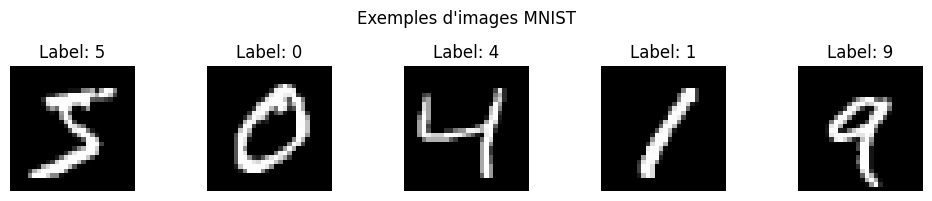

In [4]:
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Exemples d'images MNIST")
plt.tight_layout()
plt.show()

### Prétraitement des données

In [5]:
# 28x28 en un vecteurs de 784
X_train = X_train.reshape(X_train.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

# Normalisation
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Forme après aplatissement :", X_train.shape)


y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Forme des étiquettes après one-hot :", y_train.shape)
print("Exemple d'étiquette one-hot :", y_train[0])

Forme après aplatissement : (60000, 784)
Forme des étiquettes après one-hot : (60000, 10)
Exemple d'étiquette one-hot : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [6]:
model_mnist = Sequential()

# Couche cachée 1
model_mnist.add(Dense(128, activation='relu', input_shape=(784,)))

# Couche cachée 2 
model_mnist.add(Dense(64, activation='relu'))

# Couche de sortie
model_mnist.add(Dense(10, activation='softmax'))

model_mnist.summary()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Compilation 

In [7]:
model_mnist.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Entraînement du modèle

In [8]:
history_mnist = model_mnist.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9146 - loss: 0.2991 - val_accuracy: 0.9567 - val_loss: 0.1490
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9647 - loss: 0.1177 - val_accuracy: 0.9654 - val_loss: 0.1142
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9753 - loss: 0.0821 - val_accuracy: 0.9688 - val_loss: 0.1033
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9819 - loss: 0.0589 - val_accuracy: 0.9711 - val_loss: 0.0971
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9848 - loss: 0.0479 - val_accuracy: 0.9743 - val_loss: 0.0885


### Évaluation du modèle

In [9]:
test_loss, test_accuracy = model_mnist.evaluate(X_test, y_test)
print(f"\nPerte sur le test : {test_loss:.4f}")
print(f"Précision sur le test : {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9756 - loss: 0.0793

Perte sur le test : 0.0793
Précision sur le test : 0.9756


### Visualisation des courbes

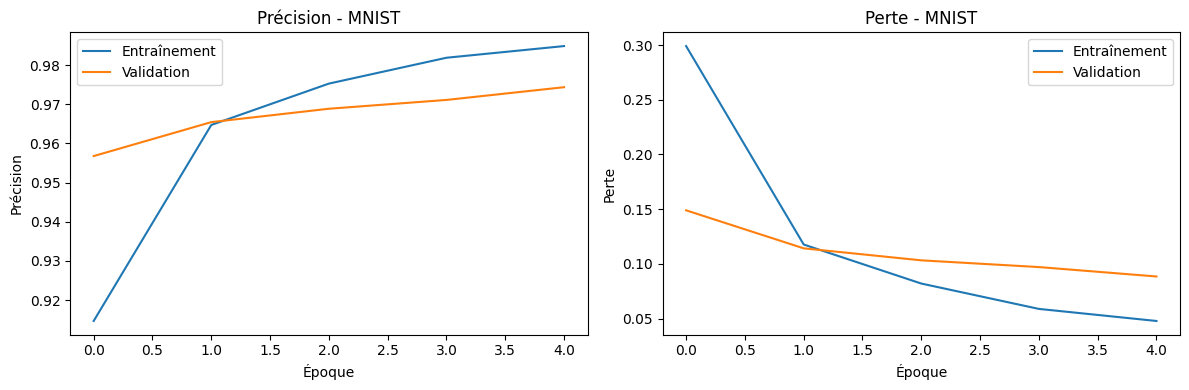

In [10]:
# La courbes de précision
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_mnist.history['accuracy'], label='Entraînement')
plt.plot(history_mnist.history['val_accuracy'], label='Validation')
plt.title('Précision - MNIST')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

# La courbes de perte
plt.subplot(1, 2, 2)
plt.plot(history_mnist.history['loss'], label='Entraînement')
plt.plot(history_mnist.history['val_loss'], label='Validation')
plt.title('Perte - MNIST')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()

plt.tight_layout()
plt.show()

---
## Exercice 02 : Implémentation d'un MLP sur le jeu de données CIFAR-10

**Objectif** : Implémenter un MLP pour la classification des images dans le jeu de données CIFAR-10.

In [42]:
!pip install torchvision
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Chargement et exploration du jeu de données CIFAR-10

In [43]:
train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

X_train_cifar = np.array(train.data)
y_train_cifar = np.array(train.targets).reshape(-1, 1)
X_test_cifar = np.array(test.data)
y_test_cifar = np.array(test.targets).reshape(-1, 1)

# Noms des classes
classes_cifar = ['avion', 'automobile', 'oiseau', 'chat', 'cerf',
                 'chien', 'grenouille', 'cheval', 'bateau', 'camion']

# Exploration
print("Taille des données d'entraînement :", X_train_cifar.shape)
print("Taille des données de test :", X_test_cifar.shape)
print("Nombre de classes :", len(classes_cifar))

HTTPError: HTTP Error 503: Service Unavailable

In [38]:
ds_train, ds_test = tfds.load('cifar10', split=['train', 'test'], as_supervised=True, batch_size=-1)
X_train_cifar, y_train_cifar = tfds.as_numpy(ds_train)
X_test_cifar, y_test_cifar = tfds.as_numpy(ds_test)

ModuleNotFoundError: No module named 'importlib_resources'

NameError: name 'X_train_cifar' is not defined

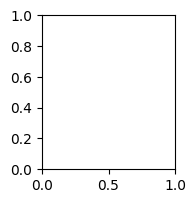

In [39]:
# Visualisation de quelques exemples
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_cifar[i])
    plt.title(classes_cifar[y_train_cifar[i][0]])
    plt.axis('off')
plt.suptitle("Exemples d'images CIFAR-10")
plt.tight_layout()
plt.show()

### Prétraitement des données

In [44]:
# Aplatir de 32x32x3 en vecteurs de 3072
X_train_cifar = X_train_cifar.reshape(X_train_cifar.shape[0], 3072)
X_test_cifar = X_test_cifar.reshape(X_test_cifar.shape[0], 3072)

# Normalisation
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar = X_test_cifar.astype('float32') / 255.0

print("Forme après aplatissement :", X_train_cifar.shape)

y_train_cifar = to_categorical(y_train_cifar, 10)
y_test_cifar = to_categorical(y_test_cifar, 10)

print("Forme des étiquettes après one-hot :", y_train_cifar.shape)

NameError: name 'X_train_cifar' is not defined

In [ ]:
model_cifar = Sequential()

# La couche cachée 1
model_cifar.add(Dense(512, activation='relu', input_shape=(3072,)))

# La couche cachée 2
model_cifar.add(Dense(256, activation='relu'))

# La couche de sortie
model_cifar.add(Dense(10, activation='softmax'))

model_cifar.summary()

### Compilation

In [ ]:
model_cifar.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Entraînement du modèle

In [ ]:
# Entraînement avec 10 époques, batch_size=64, validation_split=20%
history_cifar = model_cifar.fit(
    X_train_cifar, y_train_cifar,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

### Évaluation du modèle

In [ ]:
test_loss, test_accuracy = model_cifar.evaluate(X_test_cifar, y_test_cifar)
print(f"\nPerte sur le test : {test_loss:.4f}")
print(f"Précision sur le test : {test_accuracy:.4f}")

### Visualisation des courbes

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cifar.history['accuracy'], label='Entraînement')
plt.plot(history_cifar.history['val_accuracy'], label='Validation')
plt.title('Précision - CIFAR-10')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cifar.history['loss'], label='Entraînement')
plt.plot(history_cifar.history['val_loss'], label='Validation')
plt.title('Perte - CIFAR-10')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()

plt.tight_layout()
plt.show()

---
## Exercice 03 : Implémentation d'un MLP sur le jeu de données Breast Cancer Wisconsin

**Objectif** : Implémenter un MLP pour la classification binaire des tumeurs mammaires (bénignes ou malignes).

In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Chargement et exploration du jeu de données

In [20]:
data = load_breast_cancer()
X = data.data
y = data.target

# Exploration
print("Nombre d'instances :", X.shape[0]) 
print("Nombre d'attributs :", X.shape[1])
print("Classes :", data.target_names)
print("Distribution des classes :", np.bincount(y))

Nombre d'instances : 569
Nombre d'attributs : 30
Classes : ['malignant' 'benign']
Distribution des classes : [212 357]


### Prétraitement des données

In [21]:
# Séparation de l'entraînement du test
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisation
scaler = StandardScaler()
X_train_bc = scaler.fit_transform(X_train_bc)
X_test_bc = scaler.transform(X_test_bc)

print("Taille entraînement :", X_train_bc.shape)
print("Taille test :", X_test_bc.shape)

Taille entraînement : (455, 30)
Taille test : (114, 30)


### Construction du modèle MLP

In [22]:
model_bc = Sequential()

# Couche cachée 1
model_bc.add(Dense(64, activation='relu', input_shape=(30,)))

# Couche cachée 2
model_bc.add(Dense(32, activation='relu'))

# Couche de sortie
model_bc.add(Dense(1, activation='sigmoid'))

model_bc.summary()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

### Compilation du modèle

In [23]:
model_bc.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Entraînement du modèle

In [24]:
history_bc = model_bc.fit(
    X_train_bc, y_train_bc,
    epochs=10,
    batch_size=32
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8286 - loss: 0.4653
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9275 - loss: 0.2685
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9451 - loss: 0.1812
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9604 - loss: 0.1361
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9670 - loss: 0.1097 
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9692 - loss: 0.0939
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9736 - loss: 0.0830
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9802 - loss: 0.0742
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9824 - loss: 0.0679
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9846 - loss: 0.0627 


### Évaluation du modèl

In [25]:
test_loss, test_accuracy = model_bc.evaluate(X_test_bc, y_test_bc)
print(f"\nPerte sur le test : {test_loss:.4f}")
print(f"Précision sur le test : {test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9649 - loss: 0.0739 

Perte sur le test : 0.0739
Précision sur le test : 0.9649


### Visualisation des courbes d'apprentissage

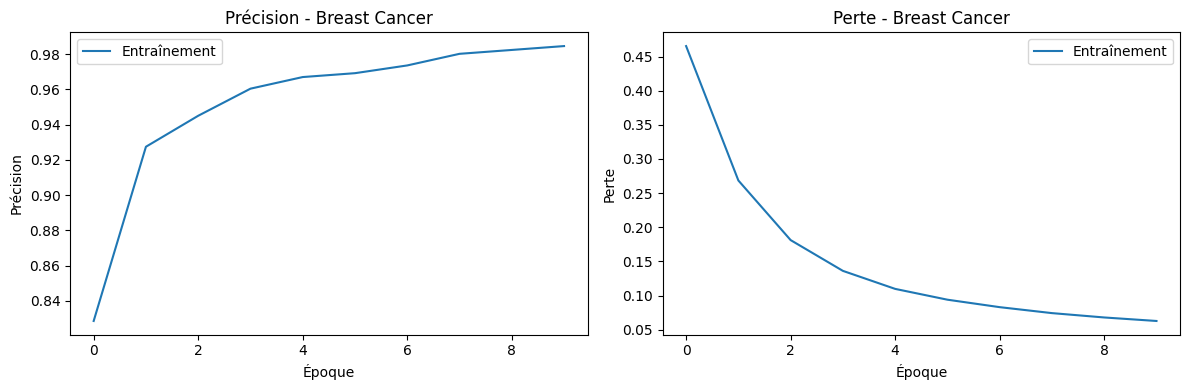

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_bc.history['accuracy'], label='Entraînement')
plt.title('Précision - Breast Cancer')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_bc.history['loss'], label='Entraînement')
plt.title('Perte - Breast Cancer')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()

plt.tight_layout()
plt.show()

---
## Exercice 04 : Implémentation d'un MLP pour la Prédiction du Prix d'une Maison (Boston Housing)

**Objectif** : Implémenter un MLP pour la régression (prédiction continue) des prix des maisons à partir du dataset Boston Housing.

In [27]:
from tensorflow.keras.datasets import boston_housing

### Chargement et exploration des données

In [28]:
(X_train_bh, y_train_bh), (X_test_bh, y_test_bh) = boston_housing.load_data()

# Exploration
print("Taille des données d'entraînement :", X_train_bh.shape)
print("Taille des données de test :", X_test_bh.shape)
print("Nombre de caractéristiques :", X_train_bh.shape[1])
print("Exemple de prix (cible) :", y_train_bh[:5])

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
Taille des données d'entraînement : (404, 13)
Taille des données de test : (102, 13)
Nombre de caractéristiques : 13
Exemple de prix (cible) : [15.2 42.3 50.  21.1 17.7]


### Prétraitement des données

In [29]:
# Normalisation des données
scaler_bh = StandardScaler()
X_train_bh = scaler_bh.fit_transform(X_train_bh)
X_test_bh = scaler_bh.transform(X_test_bh)

print("Forme des données normalisées :", X_train_bh.shape)

Forme des données normalisées : (404, 13)


### Construction du modèle MLP

In [30]:
model_bh = Sequential()

# La 1 ère couche
model_bh.add(Dense(64, activation='relu', input_shape=(13,)))

# La 2 ème couche
model_bh.add(Dense(32, activation='relu'))

# La couche de sortie
model_bh.add(Dense(1))

model_bh.summary()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compilation du modèle

In [31]:
from tensorflow.keras.metrics import RootMeanSquaredError

model_bh.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=[RootMeanSquaredError(name='rmse')]
)

### Entraînement

In [32]:
# Entraînement avec 50 époques, batch_size=32
history_bh = model_bh.fit(
    X_train_bh, y_train_bh,
    epochs=50,
    batch_size=32
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 550.1041 - rmse: 23.4543
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 506.5146 - rmse: 22.5059 
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 450.0057 - rmse: 21.2133 
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 376.0253 - rmse: 19.3914 
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 287.2501 - rmse: 16.9485
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 194.7405 - rmse: 13.9549 
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 122.4837 - rmse: 11.0672 
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 79.8907 - rmse: 8.9382   
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 60.4156 - rmse: 7.7727 
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 47.3877 - rmse: 6.8839 
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 37.7356 - rmse: 6.1429 
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31.3904 - rmse: 5.6027 

### Évaluation du modèle

In [33]:
test_loss, test_rmse = model_bh.evaluate(X_test_bh, y_test_bh)
print(f"\nPerte (MSE) sur le test : {test_loss:.4f}")
print(f"RMSE sur le test : {test_rmse:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 23.5173 - rmse: 4.8495 

Perte (MSE) sur le test : 23.5173
RMSE sur le test : 4.8495


### Visualisation des courbes d'apprentissage

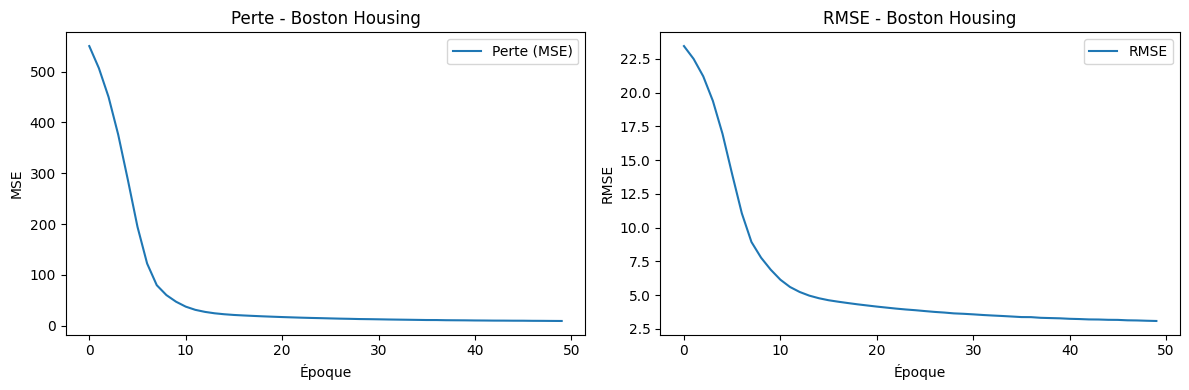

In [34]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_bh.history['loss'], label='Perte (MSE)')
plt.title('Perte - Boston Housing')
plt.xlabel('Époque')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_bh.history['rmse'], label='RMSE')
plt.title('RMSE - Boston Housing')
plt.xlabel('Époque')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.show()

### Comparaison entre la prédictions et les valeurs réelles

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


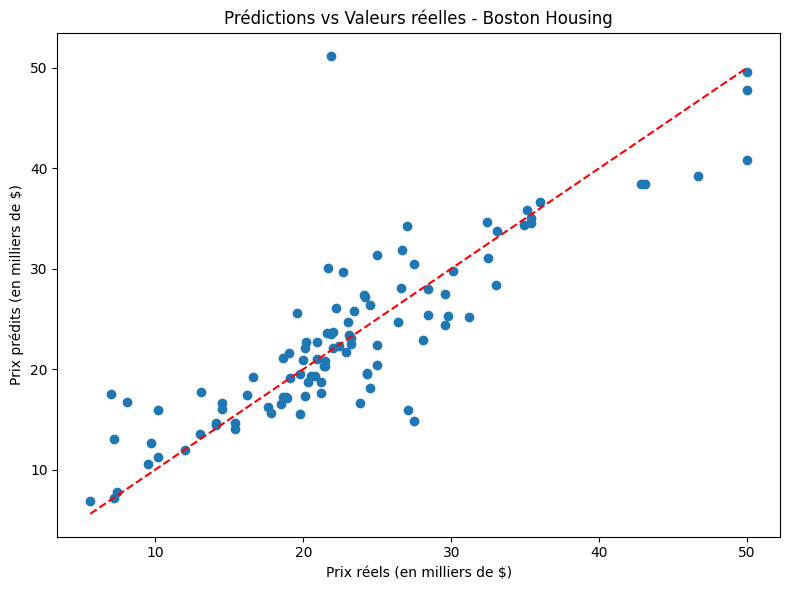

In [35]:
predictions = model_bh.predict(X_test_bh).flatten()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_bh, predictions)
plt.plot([y_test_bh.min(), y_test_bh.max()], [y_test_bh.min(), y_test_bh.max()], 'r--')
plt.xlabel('Prix réels (en milliers de $)')
plt.ylabel('Prix prédits (en milliers de $)')
plt.title('Prédictions vs Valeurs réelles - Boston Housing')
plt.tight_layout()
plt.show()